In [1]:
import os
import librosa

import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Model
import keras.backend as K
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

Loading Training dataset

In [2]:
ds_train = pd.read_csv('/Users/camcortes/Documents/birds-sounds/data/train_muestra.csv')
ds_test = pd.read_csv('/Users/camcortes/Documents/birds-sounds/data/test_muestra.csv')
ds_val = pd.read_csv('/Users/camcortes/Documents/birds-sounds/data/val_muestra.csv')
ds_train = ds_train[['audio_path', 'label']]
ds_test = ds_test[['audio_path', 'label']]
ds_val = ds_val[['audio_path', 'label']]
print(ds_train.shape)
print(ds_test.shape)
print(ds_val.shape)
ds_train.sample(5)

(798, 2)
(160, 2)
(373, 2)


,audio_path,label
330,/Users/camcortes/Documents/birds-sounds/notebo...,Mionectes oleagineus
433,/Users/camcortes/Documents/birds-sounds/notebo...,Pheugopedius coraya
546,/Users/camcortes/Documents/birds-sounds/notebo...,Cranioleuca vulpina
26,/Users/camcortes/Documents/birds-sounds/notebo...,Saltator maximus
486,/Users/camcortes/Documents/birds-sounds/notebo...,Chlorospingus flavopectus


In [3]:
# Filter broken and non-existed paths

def filter_path_non_exist(ds_train):
    print(f"Step 0: {len(ds_train)}")

    ds_train["status"] = ds_train["audio_path"].apply(lambda path: True if os.path.exists(path) else None)
    ds_train = ds_train.dropna(subset=["audio_path"])
    ds_train = ds_train.drop("status", axis=1)
    print(f"Step 1: {len(ds_train)}")

    ds_train = ds_train.sample(frac=1)
    ds_train = ds_train.reset_index(drop=True)
    print(ds_train.shape)
    
    return ds_train

ds_train = filter_path_non_exist(ds_train)
ds_test = filter_path_non_exist(ds_test)
ds_val = filter_path_non_exist(ds_val)

Step 0: 798
Step 1: 798
(798, 2)
Step 0: 160
Step 1: 160
(160, 2)
Step 0: 373
Step 1: 373
(373, 2)


In [4]:
ds_train['label'].nunique()

102

In [5]:
# label encoder
le = LabelEncoder()
ds_train['label_code'] = le.fit_transform(ds_train['label'])
ds_test['label_code'] = le.transform(ds_test['label'])
ds_val['label_code'] = le.transform(ds_val['label'])

In [6]:
# adding wav form audio
def get_audio(x):
    # manejo de excepciones
    try:
        path = x['audio_path']
        y, sr = librosa.load(path, sr=None, mono=True)
        
        # Limitar la duración del audio a 20 segundos
        max_duration = 30  # en segundos
        max_samples = sr * max_duration  # número máximo de muestras
        
        if len(y) > max_samples:
            y = y[:max_samples]
        
        return y
    except Exception as e:
        print(f'Error en {path}: {e}')
        return None


ds_train['audio'] = ds_train.apply(get_audio, axis=1)
ds_test['audio'] = ds_test.apply(get_audio, axis=1)
ds_val['audio'] = ds_val.apply(get_audio, axis=1)
ds_train.sample(2)

Note: Illegal Audio-MPEG-Header 0x6461c383 at offset 335747.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x44657374 at offset 318820.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x28547972 at offset 1564756.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x50455441 at offset 297503.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x0a000000 at offset 1018901.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x4c595249 at offset 536327.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x476f6961 at offset 59894.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x616c6c61 at o

,audio_path,label,label_code,audio
586,/Users/camcortes/Documents/birds-sounds/notebo...,Riparia riparia,73,"[0.0, 1.2532566e-12, 1.2564437e-12, -2.9013883..."
258,/Users/camcortes/Documents/birds-sounds/notebo...,Cyclarhis gujanensis,21,"[0.0, 2.6930083e-11, -7.0560696e-11, 1.2803418..."


In [7]:
ds_train.groupby("label").count()[["audio_path"]]

,audio_path
label,
Ammodramus savannarum,6
Anthus rubescens,7
Arremon assimilis,9
Arremon taciturnus,7
Arremonops conirostris,8
...,...
Vireo olivaceus,6
Volatinia jacarina,9
Xenops minutus,6


Creating dataset from train and test dataframes

In [8]:
from datasets import Dataset, DatasetDict


'''train_ds = Dataset.from_pandas(ds_train)
test_ds = Dataset.from_pandas(ds_test)
val_ds = Dataset.from_pandas(ds_val)

dataset = DatasetDict()

dataset['train'] = train_ds
dataset['test'] = test_ds
dataset['val'] = val_ds

dataset'''

"train_ds = Dataset.from_pandas(ds_train)\ntest_ds = Dataset.from_pandas(ds_test)\nval_ds = Dataset.from_pandas(ds_val)\n\ndataset = DatasetDict()\n\ndataset['train'] = train_ds\ndataset['test'] = test_ds\ndataset['val'] = val_ds\n\ndataset"

In [9]:
# guardar dataset
#dataset.save_to_disk('/Users/camcortes/Documents/birds-sounds/data/dataset')

In [10]:
from datasets import Dataset, DatasetDict

# cargar dataset
dataset = DatasetDict.load_from_disk('/Users/camcortes/Documents/birds-sounds/data/dataset')
dataset

DatasetDict({
    train: Dataset({
        features: ['audio_path', 'label', 'label_code', 'audio'],
        num_rows: 798
    })
    test: Dataset({
        features: ['audio_path', 'label', 'label_code', 'audio'],
        num_rows: 160
    })
    val: Dataset({
        features: ['audio_path', 'label', 'label_code', 'audio'],
        num_rows: 373
    })
})

Modelling

In [11]:
# We need to specify the input and output column
input_column = "audio_path"
output_column = "label"

In [12]:
# we need to distinguish the unique labels in our SER dataset
label_list = dataset['train'].unique(output_column)
label_list.sort()  # Let's sort it for determinism
num_labels = len(label_list)

In [13]:
from transformers import AutoConfig, Wav2Vec2Processor

model_name_or_path = "lighteternal/wav2vec2-large-xlsr-53-greek"
pooling_mode = "mean"

# config
config = AutoConfig.from_pretrained(
    model_name_or_path,
    num_labels=num_labels,
    label2id={label: i for i, label in enumerate(label_list)},
    id2label={i: label for i, label in enumerate(label_list)},
    finetuning_task="wav2vec2_clf",
)
setattr(config, 'pooling_mode', pooling_mode)

In [14]:
processor = Wav2Vec2Processor.from_pretrained(model_name_or_path,)
target_sampling_rate = processor.feature_extractor.sampling_rate
print(f"The target sampling rate: {target_sampling_rate}")

The target sampling rate: 16000


In [15]:
def speech_file_to_array_fn(path):
    # Carga el archivo de audio con librosa
    speech_array, sampling_rate = librosa.load(path, sr=None)  # sr=None mantiene la tasa de muestreo original
    # Si necesitas una tasa de muestreo fija, puedes resamplear directamente aquí
    if sampling_rate != target_sampling_rate:
        speech_array = librosa.resample(speech_array, orig_sr=sampling_rate, target_sr=target_sampling_rate)
    return speech_array

def label_to_id(label, label_list):
    if len(label_list) > 0:
        return label_list.index(label) if label in label_list else -1
    return label

def preprocess_function(examples):
    speech_list = [speech_file_to_array_fn(path) for path in examples[input_column]]
    target_list = [label_to_id(label, label_list) for label in examples[output_column]]

    result = processor(speech_list, sampling_rate=target_sampling_rate)
    result["labels"] = list(target_list)

    return result

In [16]:
train_dataset = dataset['train'].map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)

test_dataset = dataset['test'].map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)

val_dataset = dataset['val'].map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)

In [17]:
idx = 0
print(f"Training input_values: {train_dataset[idx]['input_values']}")
print(f"Training attention_mask: {train_dataset[idx]['attention_mask']}")
print(f"Training labels: {train_dataset[idx]['labels']} - {train_dataset[idx]['label']}")

Training input_values: [1.0392406693426892e-05, 1.0390615898359101e-05, 1.0338686479371972e-05, 1.0390615898359101e-05, 1.0324361028324347e-05, 1.0406732144474518e-05, 1.0270639904774725e-05, 1.043717384163756e-05, 1.0261686838930473e-05, 1.0569685400696471e-05, 1.0324361028324347e-05, 1.0632359590090346e-05, 9.955478162737563e-06, 1.0220500371360686e-05, 1.0258105248794891e-05, 1.0841869880096056e-05, 9.833711374085397e-06, 1.0938567356788553e-05, 1.0653848221409135e-05, 9.932199645845685e-06, 1.007366427074885e-05, 1.0775615010061301e-05, 1.1463240298326127e-05, 1.022766355163185e-05, 9.382457392348442e-06, 1.1588587767619174e-05, 1.0614452548907138e-05, 6.839677553216461e-06, 1.3844857676303945e-05, 8.046602488320787e-06, 7.3589776548033115e-06, 8.46920556796249e-06, 1.144533325714292e-05, 1.4288949387264438e-05, 1.3422255506156944e-05, 1.1332519534335006e-05, 1.7805865354603156e-05, 8.714529940334614e-06, 1.3678323739441112e-05, 1.6602522009634413e-05, 5.812145218442311e-07, 7.9060

In [18]:
from dataclasses import dataclass
from typing import Optional, Tuple
import torch
from transformers.file_utils import ModelOutput

@dataclass
class SpeechClassifierOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None

In [19]:
import torch
import torch.nn as nn
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss

from transformers.models.wav2vec2.modeling_wav2vec2 import (
    Wav2Vec2PreTrainedModel,
    Wav2Vec2Model
)


class Wav2Vec2ClassificationHead(nn.Module):
    """Head for wav2vec classification task."""

    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features, **kwargs):
        x = features
        x = self.dropout(x)
        x = self.dense(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        x = self.out_proj(x)
        return x


class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling_mode = config.pooling_mode
        self.config = config

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(config)

        self.init_weights()

    def freeze_feature_extractor(self):
        self.wav2vec2.feature_extractor._freeze_parameters()

    def merged_strategy(
            self,
            hidden_states,
            mode="mean"
    ):
        if mode == "mean":
            outputs = torch.mean(hidden_states, dim=1)
        elif mode == "sum":
            outputs = torch.sum(hidden_states, dim=1)
        elif mode == "max":
            outputs = torch.max(hidden_states, dim=1)[0]
        else:
            raise Exception(
                "The pooling method hasn't been defined! Your pooling mode must be one of these ['mean', 'sum', 'max']")

        return outputs

    def forward(
            self,
            input_values,
            attention_mask=None,
            output_attentions=None,
            output_hidden_states=None,
            return_dict=None,
            labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(
            input_values,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        hidden_states = outputs[0]
        hidden_states = self.merged_strategy(hidden_states, mode=self.pooling_mode)
        logits = self.classifier(hidden_states)

        loss = None
        if labels is not None:
            if self.config.problem_type is None:
                if self.num_labels == 1:
                    self.config.problem_type = "regression"
                elif self.num_labels > 1 and (labels.dtype == torch.long or labels.dtype == torch.int):
                    self.config.problem_type = "single_label_classification"
                else:
                    self.config.problem_type = "multi_label_classification"

            if self.config.problem_type == "regression":
                loss_fct = MSELoss()
                loss = loss_fct(logits.view(-1, self.num_labels), labels)
            elif self.config.problem_type == "single_label_classification":
                loss_fct = CrossEntropyLoss()
                loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            elif self.config.problem_type == "multi_label_classification":
                loss_fct = BCEWithLogitsLoss()
                loss = loss_fct(logits, labels)

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SpeechClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


In [20]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
import torch

import transformers
from transformers import Wav2Vec2Processor


@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        processor (:class:`~transformers.Wav2Vec2Processor`)
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
        max_length (:obj:`int`, `optional`):
            Maximum length of the ``input_values`` of the returned list and optionally padding length (see above).
        max_length_labels (:obj:`int`, `optional`):
            Maximum length of the ``labels`` returned list and optionally padding length (see above).
        pad_to_multiple_of (:obj:`int`, `optional`):
            If set will pad the sequence to a multiple of the provided value.
            This is especially useful to enable the use of Tensor Cores on NVIDIA hardware with compute capability >=
            7.5 (Volta).
    """

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [feature["labels"] for feature in features]

        d_type = torch.long if isinstance(label_features[0], int) else torch.float

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        batch["labels"] = torch.tensor(label_features, dtype=d_type)

        return batch

In [21]:
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

In [22]:
is_regression = False

In [23]:
import numpy as np
from transformers import EvalPrediction


def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    preds = np.squeeze(preds) if is_regression else np.argmax(preds, axis=1)

    if is_regression:
        return {"mse": ((preds - p.label_ids) ** 2).mean().item()}
    else:
        return {"accuracy": (preds == p.label_ids).astype(np.float32).mean().item()}

In [24]:
model = Wav2Vec2ForSpeechClassification.from_pretrained(
    model_name_or_path,
    config=config,
)

Some weights of Wav2Vec2ForSpeechClassification were not initialized from the model checkpoint at lighteternal/wav2vec2-large-xlsr-53-greek and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
model.freeze_feature_extractor()

In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_wav2vec2_xlsr",
    # output_dir="/content/gdrive/MyDrive/wav2vec2-xlsr-greek-speech-emotion-recognition"
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    evaluation_strategy="steps",
    num_train_epochs=1.0,
    fp16=False, ## cambiar a True en sagemker
    save_steps=10,
    eval_steps=10,
    logging_steps=10,
    learning_rate=1e-4,
    save_total_limit=2,
)

In [27]:
from typing import Any, Dict, Union

import torch
from packaging import version
from torch import nn

from transformers import (
    Trainer,
    is_apex_available,
)

if is_apex_available():
    from apex import amp

if version.parse(torch.__version__) >= version.parse("1.6"):
    _is_native_amp_available = True
    from torch.cuda.amp import autocast

device = torch.device('cpu')
class CTCTrainer(Trainer):
    def training_step(self, model, inputs, *args, **kwargs):
        model.train()
        inputs = self._prepare_inputs(inputs)
        # Mover inputs a la CPU
        inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
        loss = self.compute_loss(model, inputs)
        if self.args.gradient_accumulation_steps > 1:
            loss = loss / self.args.gradient_accumulation_steps
        loss.backward()
        return loss.detach()

In [28]:
trainer = CTCTrainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=processor.feature_extractor,
)

In [29]:
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [30]:
trainer.train()

  0%|          | 0/100 [00:00<?, ?it/s]

RuntimeError: slow_conv2d_forward_mps: input(device='cpu') and weight(device=mps:0')  must be on the same device

In [ ]:
tf.keras.backend.clear_session()

SAMPLING_RATE = 16000
NUM_CLASSES = 102  # Asegúrate de que este número sea correcto para tu caso
HIDDEN_DIM = 768
MAX_FRAMES = 149  # Ajustado de 150 a 149
MAX_SEQ_LENGTH = MAX_FRAMES * 320  # 149 * 320 = 47680
BATCH_SIZE = 1
MAX_EPOCHS = 2

MODEL_CHECKPOINT = "facebook/wav2vec2-base"  # Name of pretrained model from Hugging Face

In [ ]:
from transformers import AutoFeatureExtractor

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_CHECKPOINT, return_attention_mask=True
)

def preprocess_function(examples):
    audio_arrays = examples["audio"]
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=feature_extractor.sampling_rate,
        max_length=MAX_SEQ_LENGTH,
        truncation=True,
        padding=True,
    )
    return inputs


# This line with pre-process our speech_commands_v1 dataset. We also remove the "audio"
# and "file" columns as they will be of no use to us while training.
processed_dataset = dataset.map(
    preprocess_function, remove_columns=["audio", "audio_path", "label"], batched=True
)

# Load the whole dataset splits as a dict of numpy arrays
train = processed_dataset["train"].shuffle(seed=42).with_format("numpy")[:]
test = processed_dataset["test"].shuffle(seed=42).with_format("numpy")[:]
val = processed_dataset["val"].shuffle(seed=42).with_format("numpy")[:]

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [ ]:
from transformers import TFWav2Vec2Model
from transformers import TFWav2Vec2ForSequenceClassification, Wav2Vec2Processor


def mean_pool(hidden_states, feature_lengths):
    attenion_mask = tf.sequence_mask(
        feature_lengths, maxlen=MAX_FRAMES, dtype=tf.dtypes.int64
    )
    padding_mask = tf.cast(
        tf.reverse(tf.cumsum(tf.reverse(attenion_mask, [-1]), -1), [-1]),
        dtype=tf.dtypes.bool,
    )
    hidden_states = tf.where(
        tf.broadcast_to(
            tf.expand_dims(~padding_mask, -1), (BATCH_SIZE, MAX_FRAMES, HIDDEN_DIM)
        ),
        0.0,
        hidden_states,
    )
    pooled_state = tf.math.reduce_sum(hidden_states, axis=1) / tf.reshape(
        tf.math.reduce_sum(tf.cast(padding_mask, dtype=tf.dtypes.float32), axis=1),
        [-1, 1],
    )
    return pooled_state


class TFWav2Vec2ForAudioClassification(layers.Layer):
    """Combines the encoder and decoder into an end-to-end model for training."""

    def __init__(self, model_checkpoint, num_classes):
        super(TFWav2Vec2ForAudioClassification, self).__init__()
        # Instantiate the Wav2Vec 2.0 model without the Classification-Head
        self.wav2vec2 = TFWav2Vec2Model.from_pretrained(
            model_checkpoint, apply_spec_augment=False, from_pt=True
        )
        self.pooling = layers.GlobalAveragePooling1D()
        # Drop-out layer before the final Classification-Head
        self.dense1 = layers.Dense(1024, activation = 'relu')
        self.dense2 = layers.Dense(512, activation = 'relu')
        self.dense3 = layers.Dense(256, activation = 'relu')
        # Classification-Head
        self.final_layer = layers.Dense(num_classes, activation="sigmoid")

    def call(self, inputs):
        # We take only the first output in the returned dictionary corresponding to the
        # output of the last layer of Wav2vec 2.0
        hidden_states = self.wav2vec2(inputs["input_values"])[0]

        # If attention mask does exist then mean-pool only un-masked output frames
        if tf.is_tensor(inputs["attention_mask"]):
            # Get the length of each audio input by summing up the attention_mask
            # (attention_mask = (BATCH_SIZE x MAX_SEQ_LENGTH) ∈ {1,0})
            audio_lengths = tf.cumsum(inputs["attention_mask"], -1)[:, -1]
            # Get the number of Wav2Vec 2.0 output frames for each corresponding audio input
            # length
            feature_lengths = self.wav2vec2.wav2vec2._get_feat_extract_output_lengths(
                audio_lengths
            )
            pooled_state = mean_pool(hidden_states, feature_lengths)
        # If attention mask does not exist then mean-pool only all output frames
        else:
            pooled_state = self.pooling(hidden_states)

        d1 = self.dense1(pooled_state)
        d2 = self.dense2(d1)
        d3 = self.dense3(d2)
        final_state = self.final_layer(d3)
        return final_state

In [ ]:
def build_model():
    # Model's input
    inputs = {
        "input_values": tf.keras.Input(shape=(MAX_SEQ_LENGTH,), dtype="float32"),
        "attention_mask": tf.keras.Input(shape=(MAX_SEQ_LENGTH,), dtype="int32"),
    }
    # Instantiate the Wav2Vec 2.0 model with Classification-Head using the desired
    # pre-trained checkpoint
    wav2vec2_model = TFWav2Vec2ForAudioClassification(MODEL_CHECKPOINT, NUM_CLASSES)(inputs)
    # Model
    model = tf.keras.Model(inputs, wav2vec2_model)
    # Loss
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= True)
    # Optimizer
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    # Compile and return
    model.compile(loss=loss, optimizer=optimizer, metrics=["accuracy"])
    return model


model = build_model()
model.summary()


TFWav2Vec2Model has backpropagation operations that are NOT supported on CPU. If you wish to train/fine-tune this model, you need a GPU or a TPU
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFWav2Vec2Model: ['project_q.weight', 'project_q.bias', 'project_hid.weight', 'project_hid.bias', 'quantizer.codevectors', 'quantizer.weight_proj.bias', 'quantizer.weight_proj.weight']
- This IS expected if you are initializing TFWav2Vec2Model from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFWav2Vec2Model from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFWav2Vec2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the che

ValueError: Exception encountered when calling TFWav2Vec2ForAudioClassification.call().

[1mCould not automatically infer the output shape / dtype of 'tf_wav2_vec2_for_audio_classification' (of type TFWav2Vec2ForAudioClassification). Either the `TFWav2Vec2ForAudioClassification.call()` method is incorrect, or you need to implement the `TFWav2Vec2ForAudioClassification.compute_output_spec() / compute_output_shape()` method. Error encountered:

Dimensions must be equal, but are 149 and 148 for '{{node SelectV2}} = SelectV2[T=DT_FLOAT](BroadcastTo, SelectV2/t, tf_wav2_vec2_model/wav2vec2/encoder/layers.11/final_layer_norm/batchnorm/add_1)' with input shapes: [1,149,768], [], [?,148,768].[0m

Arguments received by TFWav2Vec2ForAudioClassification.call():
  • args=({'input_values': '<KerasTensor shape=(None, 47680), dtype=float32, sparse=False, name=keras_tensor>', 'attention_mask': '<KerasTensor shape=(None, 47680), dtype=int32, sparse=False, name=keras_tensor_1>'},)
  • kwargs=<class 'i

In [ ]:
import tensorflow as tf
from transformers import TFWav2Vec2Model
from tensorflow.keras import layers

NUM_CLASSES = 102  # Define el número de clases

# Modelo base preentrenado
base_model = TFWav2Vec2Model.from_pretrained("facebook/wav2vec2-base", apply_spec_augment=False, from_pt=True)
base_model.summary()


TFWav2Vec2Model has backpropagation operations that are NOT supported on CPU. If you wish to train/fine-tune this model, you need a GPU or a TPU
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFWav2Vec2Model: ['project_q.weight', 'project_q.bias', 'project_hid.weight', 'project_hid.bias', 'quantizer.codevectors', 'quantizer.weight_proj.bias', 'quantizer.weight_proj.weight']
- This IS expected if you are initializing TFWav2Vec2Model from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFWav2Vec2Model from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFWav2Vec2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the che

Model: "tf_wav2_vec2_model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 wav2vec2 (TFWav2Vec2MainLa  multiple                  94371712  
 yer)                                                            
                                                                 
Total params: 94371712 (360.00 MB)
Trainable params: 94371712 (360.00 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 16000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 16000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tf_wav2_vec2_for_a… │ (None, 10)        │  1,446,154 │ input_layer_11[0… │
│ (TFWav2Vec2ForAudi… │                   │            │ input_layer_10[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,446,154 (5.52 MB)

 Trainable params: 1,446,154 (5.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Remove targets from training dictionaries
train_x = {x: y for x, y in train.items() if x != "label_code"}
test_x = {x: y for x, y in test.items() if x != "label_code"}
val_x = {x: y for x, y in val.items() if x != "label_code"}

In [ ]:
history = model.fit(
    train_x,
    train["label_code"],
    validation_data=(val_x, val["label_code"]),
    batch_size=1,
    epochs=50,
)

Epoch 1/50


798/798 ━━━━━━━━━━━━━━━━━━━━ 102s 127ms/step - accuracy: 0.0303 - loss: 4.5632 - val_accuracy: 0.0161 - val_loss: 4.6262
Epoch 2/50
798/798 ━━━━━━━━━━━━━━━━━━━━ 102s 128ms/step - accuracy: 0.0551 - loss: 4.5348 - val_accuracy: 0.0134 - val_loss: 4.6267
Epoch 3/50
798/798 ━━━━━━━━━━━━━━━━━━━━ 104s 131ms/step - accuracy: 0.0565 - loss: 4.4964 - val_accuracy: 0.0080 - val_loss: 4.6262
Epoch 4/50
798/798 ━━━━━━━━━━━━━━━━━━━━ 105s 132ms/step - accuracy: 0.0768 - loss: 4.4747 - val_accuracy: 0.0107 - val_loss: 4.6261
Epoch 5/50
798/798 ━━━━━━━━━━━━━━━━━━━━ 102s 128ms/step - accuracy: 0.0753 - loss: 4.4341 - val_accuracy: 0.0134 - val_loss: 4.6247
Epoch 6/50
798/798 ━━━━━━━━━━━━━━━━━━━━ 102s 128ms/step - accuracy: 0.0808 - loss: 4.4003 - val_accuracy: 0.0134 - val_loss: 4.6275
Epoch 7/50
798/798 ━━━━━━━━━━━━━━━━━━━━ 104s 131ms/step - accuracy: 0.1005 - loss: 4.3724 - val_accuracy: 0.0188 - val_loss: 4.6300
Epoch 8/50
 81/798 ━━━━━━━━━━━━━━━━━━━━ 1:07 94ms/step - accuracy: 0.1104 - loss: 4.301

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

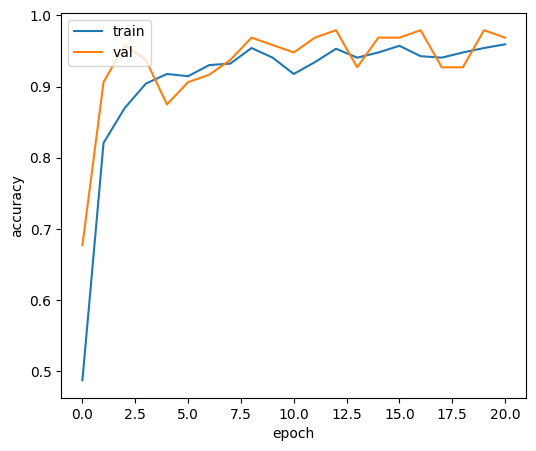

In [ ]:
plt.figure(figsize=(6, 5)) # width, height (inches)
plt.plot(history.history['accuracy'][:21])
plt.plot(history.history['val_accuracy'][:21])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

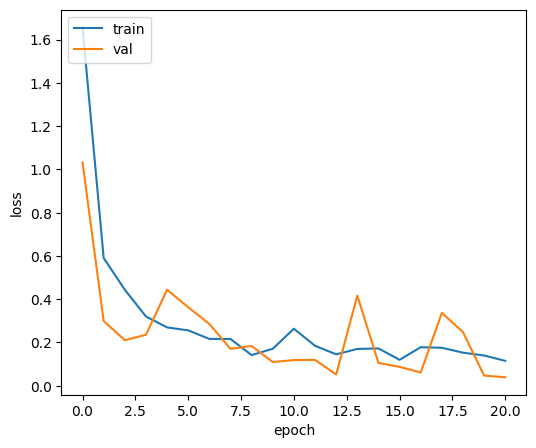

In [ ]:
plt.figure(figsize=(6, 5)) # width, height (inches)
plt.plot(history.history['loss'][:21])
plt.plot(history.history['val_loss'][:21])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#### Prediction

In [ ]:
!pip install pydub

import os
from multiprocessing import Pool

import pandas as pd
import numpy as np

from sklearn.metrics import f1_score
from scipy.sparse import lil_matrix

import tensorflow as tf
from tqdm import tqdm

import librosa
from pydub import AudioSegment
from pydub.utils import make_chunks
from IPython.display import Audio

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
#assigning numerical class labels to each bird species

cls_label = {'Asiankoel' : 0, 'bluejay': 1, 'crow': 2, 'duck': 3, 'goaway': 4, 'lapwing': 5, 'owl': 6,
             'peafowl' : 7, 'sparrow':8, 'woodpeewe':9}

########################################################

def get_class_labels(r):
  x = r['class_name']
  label_names = x.split('_')

  label_nums=[]
  for l in label_names:
    indx = cls_label[l]
    label_nums.append(indx)

  return label_nums

In [ ]:
# creating the dataframe which has path to wav file and it's label
# 2 species test dataset
label = []
path = []

root = '/content/drive/MyDrive/Bird/dataset/whole_dataset/mix_2'
for species in os.listdir(root):
    species_folder = root + '/' + species
    for audio in os.listdir(species_folder):
        audio_path = species_folder + '/' + audio
        path.append(audio_path)
        label.append(species)

df_mix_2 = pd.DataFrame({'path': path,
                         'class_name': label})

df_mix_2['class_label'] = df_mix_2.apply(get_class_labels, axis=1)

print(df_mix_2.shape)
df_mix_2.sample(5)

(334, 3)


,path,class_name,class_label
57,/content/drive/MyDrive/Bird/dataset/whole_data...,Asiankoel_duck,"[0, 3]"
194,/content/drive/MyDrive/Bird/dataset/whole_data...,woodpeewe_sparrow,"[9, 8]"
143,/content/drive/MyDrive/Bird/dataset/whole_data...,lapwing_bluejay,"[5, 1]"
34,/content/drive/MyDrive/Bird/dataset/whole_data...,Asiankoel_crow,"[0, 2]"
32,/content/drive/MyDrive/Bird/dataset/whole_data...,sparrow_duck,"[8, 3]"


In [ ]:
# 3 species test dataset
label = []
path = []

root = '/content/drive/MyDrive/Bird/dataset/whole_dataset/mix_3'
for species in os.listdir(root):
    species_folder = root + '/' + species
    for audio in os.listdir(species_folder):
        audio_path = species_folder + '/' + audio
        path.append(audio_path)
        label.append(species)

df_mix_3 = pd.DataFrame({'path': path,
                         'class_name': label})

df_mix_3['class_label'] = df_mix_3.apply(get_class_labels, axis=1)

print(df_mix_3.shape)
df_mix_3.sample(5)

(100, 3)


,path,class_name,class_label
16,/content/drive/MyDrive/Bird/dataset/whole_data...,bluejay_woodpeewe_crow,"[1, 9, 2]"
29,/content/drive/MyDrive/Bird/dataset/whole_data...,crow_sparrow_bluejay,"[2, 8, 1]"
15,/content/drive/MyDrive/Bird/dataset/whole_data...,bluejay_woodpeewe_crow,"[1, 9, 2]"
51,/content/drive/MyDrive/Bird/dataset/whole_data...,bluejay_sparrow_duck,"[1, 8, 3]"
76,/content/drive/MyDrive/Bird/dataset/whole_data...,bluejay_sparrow_goaway,"[1, 8, 4]"


In [ ]:
# whole test data i.e mixture of both 2 and 3 species audio files
df = pd.concat([df_mix_2, df_mix_3], ignore_index = True)
df.sample(5)

,path,class_name,class_label
119,/content/drive/MyDrive/Bird/dataset/whole_data...,duck_goaway,"[3, 4]"
15,/content/drive/MyDrive/Bird/dataset/whole_data...,owl_sparrow,"[6, 8]"
334,/content/drive/MyDrive/Bird/dataset/whole_data...,goaway_sparrow_bluejay,"[4, 8, 1]"
256,/content/drive/MyDrive/Bird/dataset/whole_data...,woodpeewe_lapwing,"[9, 5]"
282,/content/drive/MyDrive/Bird/dataset/whole_data...,sparrow_goaway,"[8, 4]"


In [ ]:
# ref: https://www.kaggle.com/code/arailly/multi-label-f-beta-score/notebook

def label_to_sm(labels, n_classes):
    sm = lil_matrix((len(labels), n_classes))
    for i, label in enumerate(labels):
        sm[i, label] = 1  #eg: sm[0, [2,3]] = 1
    return sm

###############################################

def get_f1_score(y_true, y_pred):
  y_true_sm = label_to_sm(labels=y_true, n_classes=10)
  y_pred_sm = label_to_sm(labels=y_pred, n_classes=10)
  metric = f1_score(y_true=y_true_sm, y_pred=y_pred_sm, average='weighted')
  return metric

#################################################

def get_sm(y_true, y_pred):
  y_true_sm = label_to_sm(labels=y_true, n_classes=10)
  y_pred_sm = label_to_sm(labels=y_pred, n_classes=10)
  return y_true_sm, y_pred_sm

In [ ]:
def get_split(path):
  myaudio = AudioSegment.from_file(path , "wav")
  chunk_length_ms = 1000 # pydub calculates in millisec
  chunks = make_chunks(myaudio, chunk_length_ms) #Make chunks of one sec

  #Export all of the individual chunks as wav files
  paths =[]

  for i, chunk in enumerate(chunks):
      chunk_name = "chunk{0}.wav".format(i)
      paths.append(chunk_name)
      chunk.export(chunk_name, format="wav")

  return paths

##################################################

def get_feature(path):
    y, sr = librosa.load(path)

    audio_arrays = [y]
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=feature_extractor.sampling_rate,
        max_length=MAX_SEQ_LENGTH,
        truncation=True,
        padding=True,
    )
    a = inputs['input_values'][0]
    a = a.reshape((1,16000))
    b = inputs['attention_mask'][0]
    b = b.reshape((1,16000))

    xq = {'input_values': a, 'attention_mask': b}

    return xq
##################################################

def get_xqs(paths):
  xqs = []
  for i in range(8): #only using first 6 chunks
    t = get_feature(paths[i])
    xqs.append(t)
  return xqs


In [ ]:
def get_probs(model, xqs):
  probs = []
  for xq in xqs:
    p = model.predict(xq, verbose = 0)
    probs.append(p)
  return np.array(probs)

def predict(model, xqs, num_species):
  probs = get_probs(model, xqs)
  # aggregrate
  s = np.max(probs, axis = 0)
  if num_species == 2:
    n = 2
  else:
    n = 3
  labels = np.argsort(s[0])[::-1][:n]
  return list(labels)

In [ ]:
def test(model, df, num_species):
  y_true = list(df['class_label'])
  y_pred = []
  for i in tqdm(range(len(df))):
    path = df['path'][i]
    chunk_paths = get_split(path)
    xqs = get_xqs(chunk_paths)
    label = predict(model, xqs, num_species)
    y_pred.append(label)
  return y_true, y_pred

#########################################################

def evaluate(model, df_mix_2, df_mix_3):
  y_true_2, y_pred_2 = test(model, df_mix_2, 2)
  y_true_3, y_pred_3 = test(model, df_mix_3, 3)

  y_true = y_true_2 + y_true_3
  y_pred = y_pred_2 + y_pred_3
  score = get_f1_score(y_true, y_pred)

  return y_true, y_pred, score

In [ ]:
y_true, y_pred, score = evaluate(model, df_mix_2, df_mix_3)
score

100%|██████████| 100/100 [01:52<00:00,  1.12s/it]


0.8289575099438417

In [ ]:
from sklearn.metrics import classification_report

y_true, y_pred = get_sm(y_true, y_pred)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.99      0.80        69
           1       0.83      0.75      0.79       101
           2       0.79      0.92      0.85       100
           3       0.90      0.72      0.80        88
           4       0.81      1.00      0.90       145
           5       1.00      0.86      0.92       136
           6       0.95      0.38      0.55        55
           7       0.54      0.62      0.58        63
           8       0.90      0.82      0.85       119
           9       0.98      0.96      0.97        92

   micro avg       0.83      0.83      0.83       968
   macro avg       0.84      0.80      0.80       968
weighted avg       0.85      0.83      0.83       968
 samples avg       0.84      0.84      0.84       968

